# CLassification 3 cancer types

# import libraries

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import numpy as np
import cv2
import os
from sklearn.utils import shuffle
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import cv2
import os
import zipfile

# token API kaggle for chest-ctscan-images dataset

In [7]:
!kaggle datasets list -s lung


ref                                                         title                                                 size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------  ----------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
mysarahmadbhat/lung-cancer                                  Lung Cancer                                           2046  2021-10-01 13:39:48.130000          52541        548  1.0              
nancyalaswad90/lung-cancer                                  Lung Cancer                                           2046  2022-07-15 19:23:28.253000          21282        220  1.0              
thedevastator/cancer-patients-and-air-pollution-a-new-link   Lung Cancer Prediction                               7532  2022-11-14 13:40:40.207000          39161        379  1.0              
jillanisofttech/lung-cancer-detection   

In [ ]:
#json token from kaggle
kaggle_folder = os.path.expanduser("~/.kaggle")
kaggle_json_path = os.path.join(kaggle_folder, "kaggle.json")


# ✅ Now download the dataset
!kaggle datasets download -d mohamedhanyyy/chest-ctscan-images --unzip


# Load datasets (train/test/valid)

In [9]:
# Function to load the dataset
def load_dataset(dataset_folder_path):
    data = []
    labels = []
    label_to_int = {}  # Dictionary to map labels to integers
    int_label = 0
    for folder_name in os.listdir(dataset_folder_path):
        if folder_name not in label_to_int:
            label_to_int[folder_name] = int_label
            int_label += 1
        folder_path = os.path.join(dataset_folder_path, folder_name)
        for image_name in os.listdir(folder_path):
            image_path = os.path.join(folder_path, image_name)
            image = cv2.imread(image_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, (224, 224))  # VGG19 input size
            data.append(image)
            labels.append(folder_name)
    # Convert the lists to numpy arrays
    data = np.array(data)
    labels = np.array(labels)
    return data, labels, label_to_int
# Load the test dataset
test_dataset_path = "C:/Users/user/Desktop/VGG16/Data/test/"
test_data, test_labels, label_to_int = load_dataset(test_dataset_path)

# Load the train dataset
train_dataset_path = "C:/Users/user/Desktop/VGG16/Data/train/"
train_data, train_labels, label_to_int = load_dataset(train_dataset_path)

# Load the validation dataset
valid_dataset_path = "C:/Users/user/Desktop/VGG16/Data/valid/"
valid_data, valid_labels, label_to_int = load_dataset(valid_dataset_path)


# Preprocessing

In [11]:
# Shuffle the datasets
train_data, train_labels = shuffle(train_data, train_labels, random_state=42)
test_data, test_labels = shuffle(test_data, test_labels, random_state=42)
valid_data, valid_labels = shuffle(valid_data, valid_labels, random_state=42)

# Normalize the pixel values to [0, 1]
train_data = train_data.astype('float32') / 255.0
test_data = test_data.astype('float32') / 255.0
valid_data = valid_data.astype('float32') / 255.0

# Convert the labels to integers using label_to_int dictionary
train_labels_mapped = np.array([label_to_int[label] for label in train_labels])
# Convert the labels to integers using label_to_int dictionary
train_labels_mapped = np.array([label_to_int[label] for label in train_labels])

# Convert the labels to integers using label_to_int dictionary
test_labels_mapped = []
for label in test_labels:
    if label in label_to_int:
        test_labels_mapped.append(label_to_int[label])
    else:
        # Handle missing or unexpected labels (e.g., assign a unique integer or skip the sample)
        # You can also ignore the sample if needed.
        pass

test_labels_mapped = np.array(test_labels_mapped)
# Convert the labels to integers using label_to_int dictionary
valid_labels_mapped = np.array([label_to_int[label] for label in valid_labels])
valid_labels_mapped = np.array([label_to_int[label] for label in valid_labels])
# Convert the labels to one-hot encoded vectors
num_classes = len(label_to_int)
train_labels = tf.keras.utils.to_categorical(train_labels_mapped, num_classes)
test_labels = tf.keras.utils.to_categorical(test_labels_mapped, num_classes)
valid_labels = tf.keras.utils.to_categorical(valid_labels_mapped, num_classes)

# Split

In [13]:
from sklearn.model_selection import train_test_split
# Split the original training dataset into new training and test datasets
new_train_data, new_test_data, new_train_labels, new_test_labels = train_test_split(
    train_data, train_labels, test_size=0.2, random_state=42
)
# Combine the new training and test datasets
combined_data = np.concatenate((new_train_data, new_test_data), axis=0)
combined_labels = np.concatenate((new_train_labels, new_test_labels), axis=0)

# Shuffle the combined dataset
combined_data, combined_labels = shuffle(combined_data, combined_labels, random_state=42)

# Split the shuffled dataset into final training and test datasets
train_data, test_data, train_labels, test_labels = train_test_split(
    combined_data, combined_labels, test_size=0.2, random_state=42
)

# Print the sizes of the final datasets
print("Final training dataset size:", len(train_data))
print("Final test dataset size:", len(test_data))

Final training dataset size: 490
Final test dataset size: 123


#  build a VGG19 

In [15]:
# Build VGG19 model , Very Deep Convolutional Networks for Large-Scale Image Recognition
input_shape = (224, 224, 3)  # VGG19 input size
input_layer = Input(shape=input_shape)
#The code creates the VGG19 model by stacking various layers to form five convolutional blocks.
#Each block consists of multiple convolutional layers followed by max-pooling.
#The padding='same' argument ensures that the spatial dimensions of the output remain the same as the input.
#The max-pooling layers (MaxPooling2D) reduce the spatial dimensions of the feature maps while retaining their important features.
# Block 1
x = Conv2D(64, (3, 3), activation='relu', padding='same', name='block1_conv1')(input_layer)
x = Conv2D(64, (3, 3), activation='relu', padding='same', name='block1_conv2')(x)
x = MaxPooling2D((2, 2), strides=(2, 2), name='block1_pool')(x)
# Block 2
x = Conv2D(128, (3, 3), activation='relu', padding='same', name='block2_conv1')(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same', name='block2_conv2')(x)
x = MaxPooling2D((2, 2), strides=(2, 2), name='block2_pool')(x)
# Block 3
x = Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv1')(x)
x = Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv2')(x)
x = Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv3')(x)
x = Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv4')(x)
x = MaxPooling2D((2, 2), strides=(2, 2), name='block3_pool')(x)
# Block 4
x = Conv2D(512, (3, 3), activation='relu', padding='same', name='block4_conv1')(x)
x = Conv2D(512, (3, 3), activation='relu', padding='same', name='block4_conv2')(x)
x = Conv2D(512, (3, 3), activation='relu', padding='same', name='block4_conv3')(x)
x = Conv2D(512, (3, 3), activation='relu', padding='same', name='block4_conv4')(x)
x = MaxPooling2D((2, 2), strides=(2, 2), name='block4_pool')(x)
# Block 5
x = Conv2D(512, (3, 3), activation='relu', padding='same', name='block5_conv1')(x)
x = Conv2D(512, (3, 3), activation='relu', padding='same', name='block5_conv2')(x)
x = Conv2D(512, (3, 3), activation='relu', padding='same', name='block5_conv3')(x)
x = Conv2D(512, (3, 3), activation='relu', padding='same', name='block5_conv4')(x)
x = MaxPooling2D((2, 2), strides=(2, 2), name='block5_pool')(x)
#convert 2d into 1d
x = Flatten(name='flatten')(x)
x = Dense(4096, activation='relu', name='fc1')(x)
x = Dense(4096, activation='relu', name='fc2')(x)
output_layer = Dense(num_classes, activation='softmax', name='predictions')(x)
vgg19_model = Model(inputs=input_layer, outputs=output_layer)
# Compile the model
vgg19_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
vgg19_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv4 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv4 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv4 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 139,586,628 (532.48 MB)

 Trainable params: 139,586,628 (532.48 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
print(len(train_data), len(train_labels))
print(len(test_data), len(test_labels))
print(len(valid_data), len(valid_labels))

490 490
123 123
72 72


In [21]:
# Optimize batch size and epochs
batch_size = 16  # Smaller batch = lower memory usage
epochs = 5       # Fewer epochs = faster training

# Enable performance boost with `shuffle=True` and `verbose=1`
history = vgg19_model.fit(
    train_data,
    train_labels,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(test_data, test_labels),
    shuffle=True,
    verbose=1
)

Epoch 1/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 796s 25s/step - accuracy: 0.2700 - loss: 1.5678 - val_accuracy: 0.3496 - val_loss: 1.3624
Epoch 2/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 874s 28s/step - accuracy: 0.2998 - loss: 1.3830 - val_accuracy: 0.3496 - val_loss: 1.3651
Epoch 3/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1179s 38s/step - accuracy: 0.3190 - loss: 1.3708 - val_accuracy: 0.3496 - val_loss: 1.3656
Epoch 4/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1893s 61s/step - accuracy: 0.3177 - loss: 1.3692 - val_accuracy: 0.3496 - val_loss: 1.3660
Epoch 5/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 2028s 66s/step - accuracy: 0.3185 - loss: 1.3728 - val_accuracy: 0.3496 - val_loss: 1.3632


In [23]:
test_loss, test_accuracy = vgg19_model.evaluate(test_data, test_labels, batch_size=batch_size)
print('Test Loss:', test_loss)
print('Test Accuracy:', test_accuracy)

8/8 ━━━━━━━━━━━━━━━━━━━━ 86s 11s/step - accuracy: 0.3865 - loss: 1.3478
Test Loss: 1.3632152080535889
Test Accuracy: 0.34959349036216736


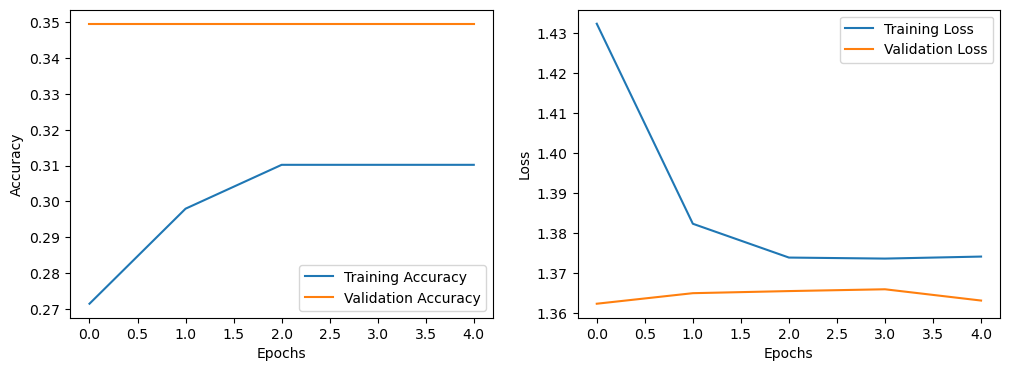

In [25]:
def plot_history(history):
    plt.figure(figsize=(12, 4))
    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()
# Plot the training history
plot_history(history)

4/4 ━━━━━━━━━━━━━━━━━━━━ 84s 20s/step


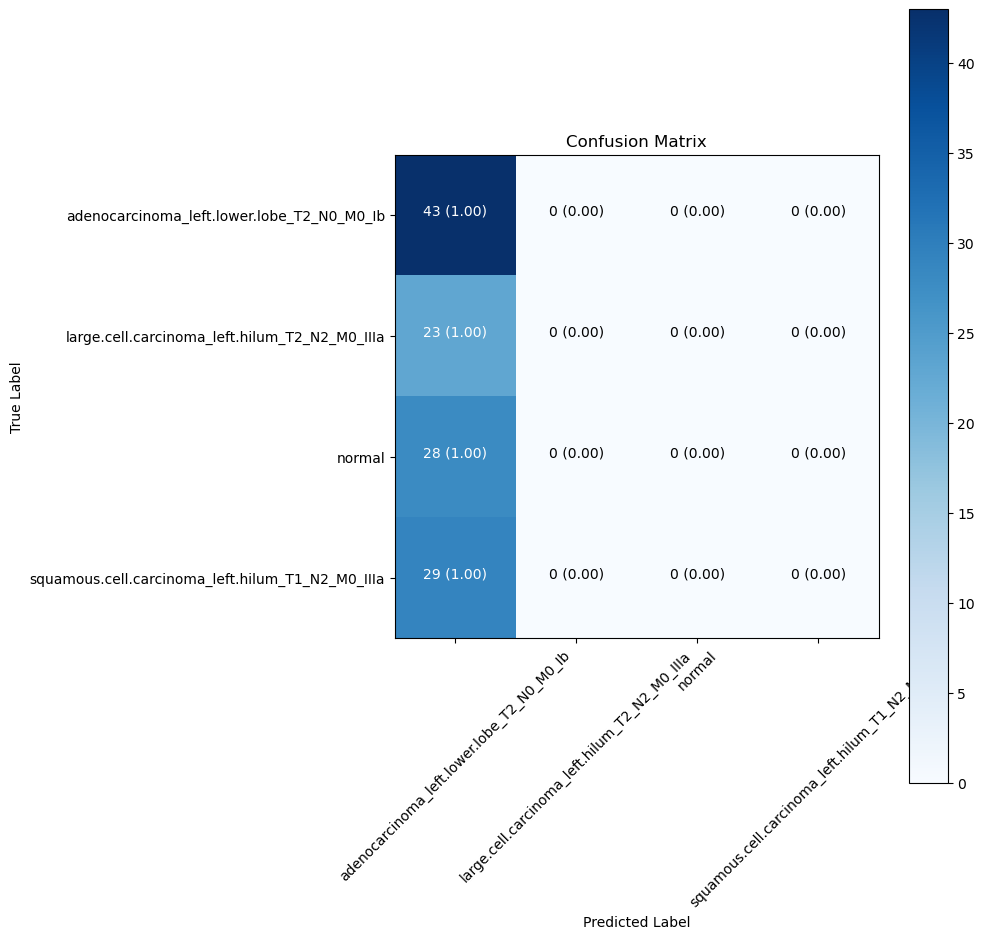

In [27]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
# Assuming you have already trained your vgg19_model and obtained predictions on the test set
predictions = vgg19_model.predict(test_data)
predicted_labels = np.argmax(predictions, axis=1)

# Compute the confusion matrix
cm = confusion_matrix(np.argmax(test_labels, axis=1), predicted_labels)

# Get class labels from the label_to_int dictionary
label_to_int_inv = {v: k for k, v in label_to_int.items()}
classes = [label_to_int_inv[i] for i in range(num_classes)]

# Plot the confusion matrix
plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

# Normalize the confusion matrix values for better readability
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Use white text for darker cells, and black text otherwise
thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], 'd') + " (" + format(cm_normalized[i, j], '.2f') + ")",
             horizontalalignment='center', color='white' if cm[i, j] > thresh else 'black')
plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [29]:
from sklearn.metrics import accuracy_score
# Assuming you have already trained your model and obtained predictions on the test set
# predictions = model.predict(test_data)
# predicted_labels = np.argmax(predictions, axis=1)
# Compute the accuracy
accuracy = accuracy_score(np.argmax(test_labels, axis=1), predicted_labels)
# Display the accuracy percentage
print("Accuracy: {:.2f}%".format(accuracy * 100))
     

Accuracy: 34.96%


In [31]:

from sklearn.metrics import classification_report
# Assuming you have already trained your model and obtained predictions on the test set
# predictions = model.predict(test_data)
# predicted_labels = np.argmax(predictions, axis=1)
# Compute the classification report
report = classification_report(np.argmax(test_labels, axis=1), predicted_labels)
# Display the classification report
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.35      1.00      0.52        43
           1       0.00      0.00      0.00        23
           2       0.00      0.00      0.00        28
           3       0.00      0.00      0.00        29

    accuracy                           0.35       123
   macro avg       0.09      0.25      0.13       123
weighted avg       0.12      0.35      0.18       123



C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [33]:
from sklearn.metrics import precision_score, recall_score, f1_score
precision = precision_score(np.argmax(test_labels, axis=1), predicted_labels, average='weighted')
recall = recall_score(np.argmax(test_labels, axis=1), predicted_labels, average='weighted')
f1 = f1_score(np.argmax(test_labels, axis=1), predicted_labels, average='weighted')
print("Precision: {:.2f}".format(precision))
print("Recall: {:.2f}".format(recall))
print("F1-Score: {:.2f}".format(f1))

Precision: 0.12
Recall: 0.35
F1-Score: 0.18


C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


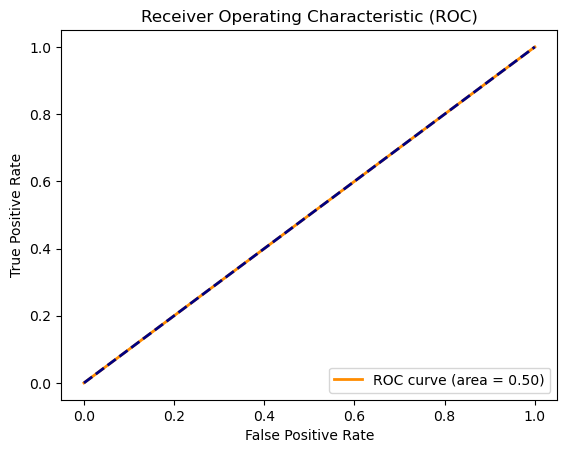

In [35]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
# Assuming binary classification (two classes) for simplicity
# If your problem is multi-class, you need to modify the code accordingly
fpr, tpr, thresholds = roc_curve(test_labels[:, 1], predictions[:, 1])
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

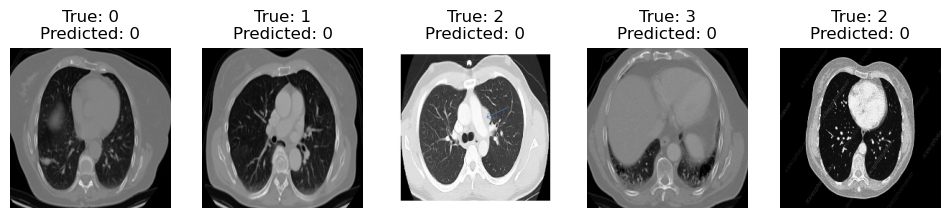

In [37]:
import random
# Assuming you have already trained your model and obtained predictions on the test set
# predictions = model.predict(test_data)
# predicted_labels = np.argmax(predictions, axis=1)
# Choose a random subset of test data and corresponding true and predicted labels
random_indices = random.sample(range(len(test_data)), 5)
sample_images = test_data[random_indices]
sample_true_labels = np.argmax(test_labels[random_indices], axis=1)
sample_predicted_labels = predicted_labels[random_indices]
# Visualize the sample images with true and predicted labels
plt.figure(figsize=(12, 6))
for i in range(len(sample_images)):
    plt.subplot(1, 5, i + 1)
    plt.imshow(sample_images[i])
    plt.title(f"True: {sample_true_labels[i]}\nPredicted: {sample_predicted_labels[i]}")
    plt.axis('off')
plt.show()

include_top=False argument ensures that the top classification layers of VGG19 are not included,so you can add your own custom layers later.output of the VGG19 model is fed into a Flatten() layer to convert the 4D tensor into a 2D tensor.two fully connected (Dense) layers with 4096 units and ReLU activation are added.the output layer with num_classes units and a softmax activation function is added where num_classes is the number of classes in your dataset.you freeze the pre-trained layers of the VGG19 model to avoid overfitting on your limited dataset. In this step, the model is compiled with the Adam optimizer using a lower learning rate (0.0001) for fine-tuning .

# Pretrained VGG (Transfer learning)

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 224s 12s/step - accuracy: 0.3800 - loss: 2.8398 - val_accuracy: 0.6423 - val_loss: 0.8011
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 200s 12s/step - accuracy: 0.7524 - loss: 0.6534 - val_accuracy: 0.6911 - val_loss: 0.6454
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 204s 13s/step - accuracy: 0.8312 - loss: 0.4605 - val_accuracy: 0.8699 - val_loss: 0.3423
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 210s 13s/step - accuracy: 0.9488 - loss: 0.2239 - val_accuracy: 0.8699 - val_loss: 0.3540
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 259s 16s/step - accuracy: 0.9762 - loss: 0.1252 - val_accuracy: 0.9350 - val_loss: 0.2190
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 224s 13s/step - accuracy: 0.9722 - loss: 0.0898 - val_accuracy: 0.9187 - val_loss: 0.2137
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 216s 12s/step - accuracy: 0.9910 - loss: 0.0501 - val_accuracy: 0.8943 - val_loss: 0.2099
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 215s 13s/step - accuracy: 0.9949 - loss: 0.0374 - val_accuracy: 0.

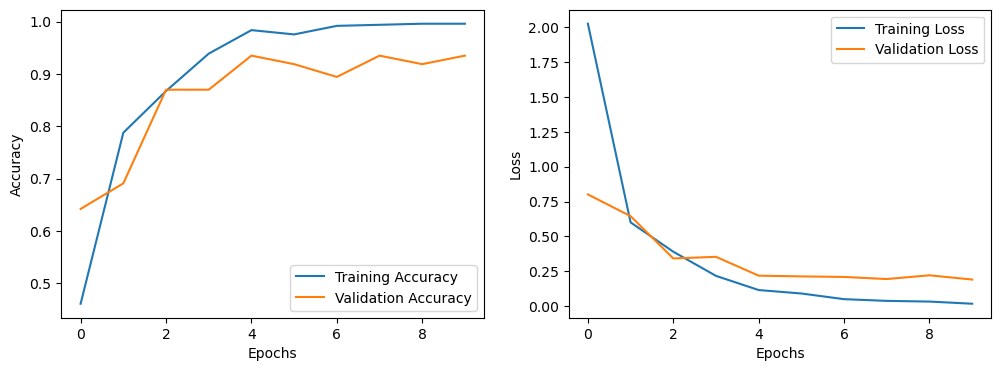

In [48]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Flatten, Dense
from tensorflow.keras.optimizers import Adam
# Step 1: Load a pre-trained VGG19 model with pre-trained weights and without the final classification layers
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Step 2: Add your own classification layers on top of the pre-trained VGG19 model
x = base_model.output
x = Flatten()(x)
x = Dense(4096, activation='relu')(x)
x = Dense(4096, activation='relu')(x)
output_layer = Dense(num_classes, activation='softmax')(x)

# Step 3: Freeze the pre-trained layers to avoid overfitting on your limited dataset
for layer in base_model.layers:
    layer.trainable = False

# Step 4: Create the fine-tuned model by combining the base VGG19 model with your classification layers
fine_tuned_model = Model(inputs=base_model.input, outputs=output_layer)

# Step 5: Compile the model with a lower learning rate for fine-tuning
optimizer = Adam(learning_rate=0.0001)
fine_tuned_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
# Save the model to a file (e.g., "my_fine_tuned_model.h5")
model_save_path = "my_fine_tuned_model.h5"
fine_tuned_model.save(model_save_path)

# Fine-tune the model with your training data
batch_size = 32
epochs = 10

history = fine_tuned_model.fit(train_data, train_labels, batch_size=batch_size, epochs=epochs, validation_data=(test_data, test_labels))

# Evaluate the fine-tuned model on the test set
test_loss, test_accuracy = fine_tuned_model.evaluate(test_data, test_labels, batch_size=batch_size)
print('Test Loss:', test_loss)
print('Test Accuracy:', test_accuracy)

# Plot the training history
plot_history(history)

4/4 ━━━━━━━━━━━━━━━━━━━━ 36s 9s/step


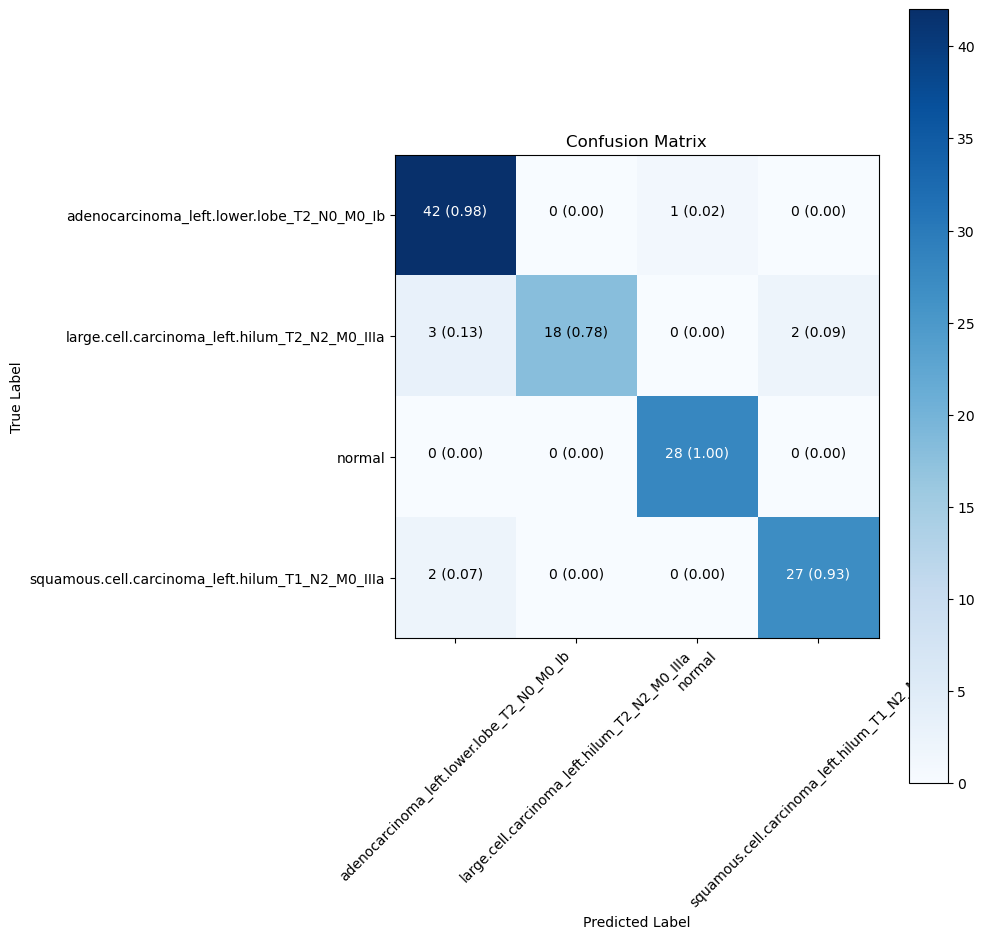

Accuracy: 93.50%


In [50]:
# Assuming you have already fine-tuned your model and obtained predictions on the test set
predictions = fine_tuned_model.predict(test_data)
predicted_labels = np.argmax(predictions, axis=1)
# Compute the confusion matrix
cm = confusion_matrix(np.argmax(test_labels, axis=1), predicted_labels)
# Get class labels from the label_to_int dictionary
label_to_int_inv = {v: k for k, v in label_to_int.items()}
classes = [label_to_int_inv[i] for i in range(num_classes)]
# Plot the confusion matrix
plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)
# Normalize the confusion matrix values for better readability
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
# Use white text for darker cells, and black text otherwise
thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], 'd') + " (" + format(cm_normalized[i, j], '.2f') + ")",
             horizontalalignment='center', color='white' if cm[i, j] > thresh else 'black')
plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()
from sklearn.metrics import accuracy_score
# Compute the accuracy
accuracy = accuracy_score(np.argmax(test_labels, axis=1), predicted_labels)
# Display the accuracy percentage
print("Accuracy: {:.2f}%".format(accuracy * 100))

Please enter the full path to a CT scan image file (e.g., C:/path/to/image.png):
 C:/Users/user/Desktop/VGG16/Data/valid/large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa/000108.png


Original mode: RGBA
Converted mode: RGB
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


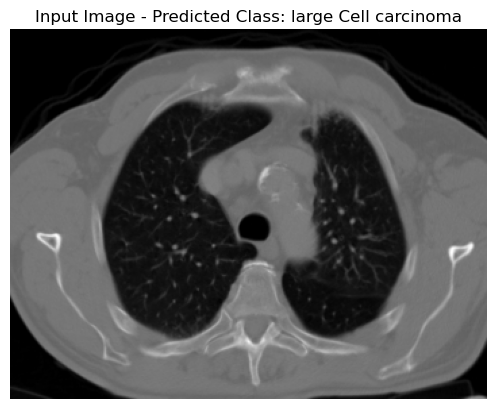

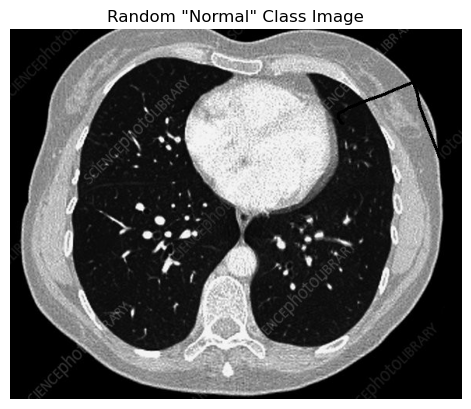

In [5]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array
from PIL import Image

# Ask user to enter image path manually
input_image_path = input("Please enter the full path to a CT scan image file (e.g., C:/path/to/image.png):\n")

# Define class labels
label_to_int = {
    "adenocarcinoma": 0,
    "large Cell carcinoma": 1,
    "normal": 2,
    "squamous.cell.carcinoma": 3
}

# Preprocessing function
def preprocess_input_image(image_path, input_shape):
    image = Image.open(image_path)
    print("Original mode:", image.mode)  # Debug line
    image = image.convert("RGB")
    print("Converted mode:", image.mode)  # Should be RGB
    image = image.resize(input_shape)
    image = img_to_array(image)
    image = image.astype('float32') / 255.0
    image = np.expand_dims(image, axis=0)
    return image


# Load the trained model
fine_tuned_model = load_model("C:/Users/user/Downloads/my_fine_tuned_model.h5")

# Preprocess and predict
input_shape = (224, 224)
input_image = preprocess_input_image(input_image_path, input_shape)
predictions = fine_tuned_model.predict(input_image)
predicted_label = list(label_to_int.keys())[np.argmax(predictions)]

# Display input image
input_display = Image.open(input_image_path)
plt.imshow(input_display)
plt.title(f'Input Image - Predicted Class: {predicted_label}')
plt.axis('off')
plt.show()

# Show a random normal image
normal_images_path = "C:/Users/user/Desktop/VGG16/Data/valid/normal"
normal_images = os.listdir(normal_images_path)
random_normal_image = random.choice(normal_images)
output_image_path = os.path.join(normal_images_path, random_normal_image)
output_image = Image.open(output_image_path)
plt.imshow(output_image)
plt.title('Random "Normal" Class Image')
plt.axis('off')
plt.show()
